# RF regression on sequence with one hot spot

Minimal, readable pipeline split into cells.

In [1]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18


## 1) Imports & config

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from scipy.interpolate import PchipInterpolator
    _HAVE_PCHIP = True
except Exception:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
    _HAVE_PCHIP = False

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("span", 5, 23)                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

RF_PARAMS = dict(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
)


## 2) Utilities: one‑hot featurizer


onehot_positional	Converts each DNA sequence into a one-hot encoded numeric array (mononucleotide level)	DataFrame of 0s and 1s
Model trains on:	The frequency/pattern of each nucleotide (A/C/G/T) at each specific positio.Global features (cheap, effective):


In [ ]:
import numpy as np
import pandas as pd

SEQ_COL = "sequence"          # adapt if needed
KEEP_WINDOW = ("span", 5, 23)      # 19 positions -> 19 * 4 = 76 features


def build_X(
    df: pd.DataFrame,
    window=KEEP_WINDOW,          # ("all",0,0) or ("span", start, end)
    kmer_ks=None,           # kept for compatibility, ignored
    collapse_rc=True,       # kept for compatibility, ignored
    add_global=False        # kept for compatibility, ignored
) -> pd.DataFrame:
    """
    NEW positional-only build_X:

    - Sequences are uppercased, U->T, non-ACGT removed.
    - A fixed window (start..end, inclusive) is used.
    - For each position we create 4 binary features (A,C,G,T).
    - NO global features, NO k-mers.

    Total features = (end - start + 1) * 4.
    With WINDOW = ("span", 5, 23) -> 19 positions -> 76 features.
    """
    NUCS = "ACGT"

    # normalize sequences
    seqs = (
        df[SEQ_COL]
        .astype(str)
        .str.upper()
        .str.replace("U", "T", regex=False)
        .map(lambda s: "".join(ch for ch in s if ch in NUCS))
    )

    # window
    if window[0] == "all":
        L = seqs.str.len().min()
        start, end = 0, L - 1
    else:
        _, start, end = window

    n_pos = end - start + 1

    # positional mono one-hot
    cols = [f"pos{p}_{n}" for p in range(start, end + 1) for n in NUCS]
    Xpos = np.zeros((len(seqs), n_pos * 4), float)

    for i, s in enumerate(seqs):
        # pad with N so indexing is safe
        s_padded = (s + "N" * (end + 1 - len(s)))[: end + 1]
        for p in range(start, end + 1):
            b = s_padded[p]
            if b in NUCS:
                Xpos[i, (p - start) * 4 + NUCS.index(b)] = 1.0

    X = pd.DataFrame(Xpos, columns=cols, index=df.index)
    return X


## 4) Train, calibrate, evaluate

In [4]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np, pandas as pd

# 1) Load & filter
df = pd.read_csv(INFILE)
#df = pd.read_csv("merged_output_balanced.csv")
df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Features (ensure build_X does NOT impute; we impute AFTER the split)
X = build_X(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED,
    stratify=bins if bins is not None else None
)
# 6) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    """Return higher weights for low and high tails of y."""
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)




#rf.fit(Xtr, ytr, sample_weight=wtr)
#rf.fit(Xtr, ytr, sample_weight=wtr)
rf_unw = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS).fit(Xtr, ytr)
rf_w   = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS).fit(Xtr, ytr, sample_weight=wtr)
print("Train R² unweighted:", r2_score(ytr, rf_unw.predict(Xtr)))
print("Train R² weighted:",   r2_score(ytr, rf_w.predict(Xtr)))


# 7) Model: define ONCE, fit ONCE with weights
rf = RandomForestRegressor(random_state=SEED, n_jobs=-1, **RF_PARAMS)
rf.fit(Xtr, ytr, sample_weight=wtr)



Train R² unweighted: 0.8573940900390816
Train R² weighted: 0.8684294669445223


,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [5]:
# 8) Predictions
yhat_tr  = rf.predict(Xtr)
yhat_raw = rf.predict(Xte)

# 9) No-leak calibrator: OOF isotonic on train predictions
import numpy as np
from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression

def fit_calibrator_oof_pred(y_pred_train, y_train, n_splits=5, seed=123):
    """
    Fit isotonic regression on TRAIN ONLY using K-fold OOF predictions
    and return a ('iso', fitted_model) tuple suitable for saving.
    """
    y_pred_train = np.asarray(y_pred_train, float)
    y_train      = np.asarray(y_train, float)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.empty_like(y_train, float)

    for tr, va in kf.split(y_pred_train):
        iso_k = IsotonicRegression(increasing=True, out_of_bounds="clip")
        iso_k.fit(y_pred_train[tr], y_train[tr])
        oof[va] = iso_k.predict(y_pred_train[va])

    # final calibrator refit on *all* train data
    iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
    iso.fit(y_pred_train, y_train)
    return ("iso", iso)

def apply_calibrator(y_pred, calibrator):
    """
    Apply a saved calibrator tuple to predictions.
    Supports ('iso', model) and ('qmap', {'xp':..., 'fp':...}).
    """
    kind, obj = calibrator
    y_pred = np.asarray(y_pred, float)
    if kind == "iso":
        return obj.predict(y_pred)
    elif kind == "qmap":
        return np.interp(y_pred, obj["xp"], obj["fp"])
    else:
        return y_pred  # no-op fallback


# 10) Metrics
# Ensure we have test preds in `yhat`
if 'yhat' not in locals():
    if 'yhat_te' in locals():
        yhat = yhat_te_seq
    else:
        # fall back: compute now
        s_te = rf.predict(Xte)
        try:
            yhat = apply_calibrator(s_te, calib)  # if you use calibration
        except Exception:
            yhat = s_te

assert 'yte' in locals(), "yte not defined"
assert len(yhat) == len(yte), "Pred/true length mismatch"

r2   = r2_score(yte, yhat)
rmse = mean_squared_error(yte, yhat) ** 0.5
mae  = mean_absolute_error(yte, yhat)
print(f"R²={r2:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}")


R²=0.812 | RMSE=0.141 | MAE=0.110


## 5) Plots & saving predictions

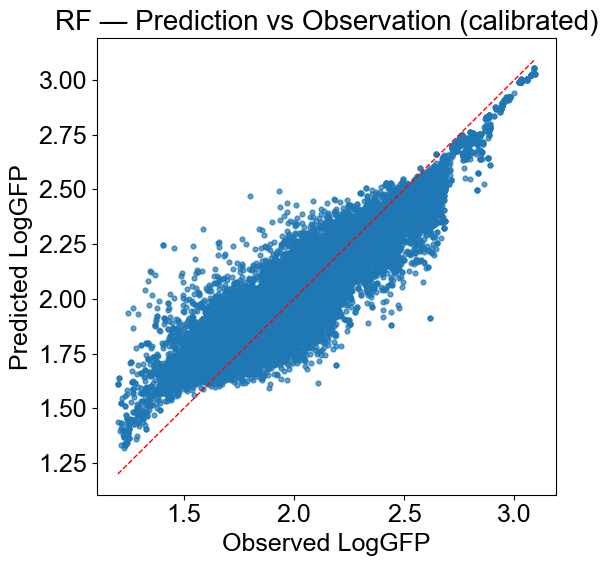

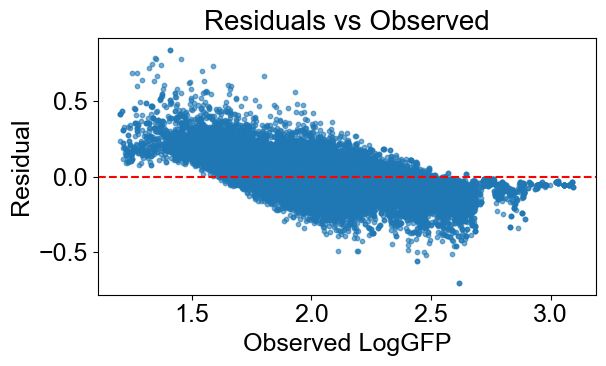

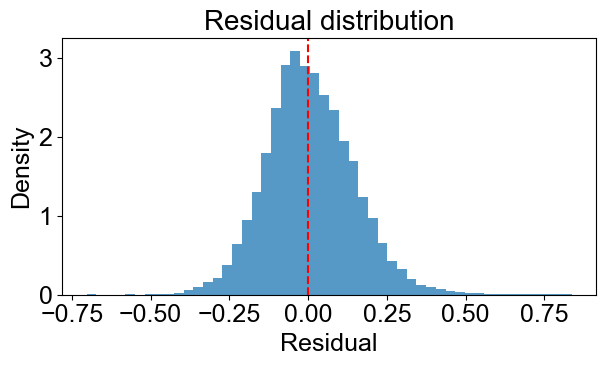

Mean residual: 0.006276336746891783


In [6]:
def show_and_save(fig, name):
    fig.tight_layout(); fig.savefig(f"{OUT}_{name}.png", dpi=300); plt.show(); plt.close(fig)

fig = plt.figure(figsize=(6,6))
plt.scatter(yte, yhat, s=12, alpha=0.7)
lo,hi = float(min(yte.min(),yhat.min())), float(max(yte.max(),yhat.max()))
plt.plot([lo,hi],[lo,hi],'r--',lw=1)
plt.xlabel("Observed LogGFP"); plt.ylabel("Predicted LogGFP")
plt.title("RF — Prediction vs Observation (calibrated)")
show_and_save(fig, "pred_vs_obs")

res = yhat - yte
fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte,res,s=10,alpha=0.6); plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP"); plt.ylabel("Residual")
plt.title("Residuals vs Observed")
show_and_save(fig, "residuals_vs_obs")

fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--'); plt.xlabel("Residual"); plt.ylabel("Density")
plt.title("Residual distribution")
show_and_save(fig, "residual_hist")

pd.DataFrame({"y_true":yte, "y_pred_raw":yhat_raw, "y_pred":yhat}).to_csv(f"{OUT}_preds.csv", index=False)
bias = res.mean()
print("Mean residual:", bias)

In [7]:
print(f"Train R² = {r2_score(ytr, yhat_tr):.3f}")
print(f"Test  R² = {r2_score(yte, yhat):.3f}")


Train R² = 0.868
Test  R² = 0.812


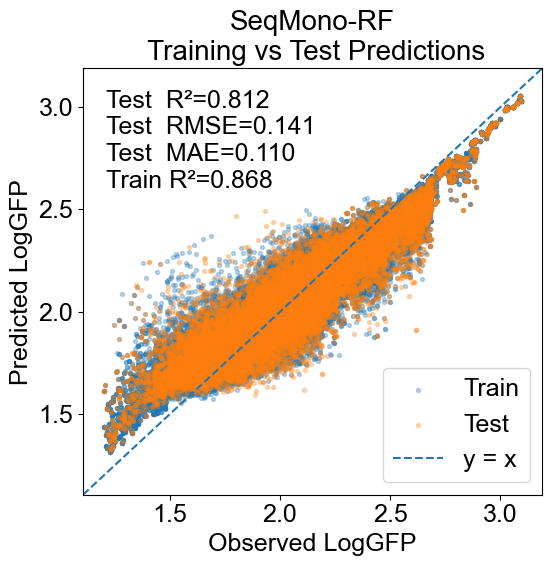

Saved figure -> rf_train_vs_test.png


In [8]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF — Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("RF-sequence-based-mono-feature — Training vs Test Predictions.png", dpi=600)
    plt.savefig(
    " RF-sequence-based-mono-featurevs Test Predictions.pdf",
    bbox_inches="tight")
    
    plt.show()
    print(f"Saved figure -> {out_png}")

# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="SeqMono-RF\n"" Training vs Test Predictions",
                        out_png="rf_train_vs_test.png")

# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


In [9]:
# --- Prepare predictions if not already defined ---
try:
    yhat_te_seq
except NameError:
    # if calibrated predictions exist:
    if 'calib' in locals():
        s_te = rf.predict(Xte)
        yhat_te_seq = apply_calibrator(s_te, calib)
    else:
        # otherwise just use raw predictions
        yhat_te_seq = rf.predict(Xte)
        
        pd.DataFrame({"yte": yte, "yhat_te_seq": yhat_te_seq}).to_csv("seq_model_results.csv", index=False)


BEESWARM

In [10]:
def make_shap_beeswarm_fast(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5, 3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )
    plt.title(title, loc="left")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath:
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)

    plt.show()


Saving to: /Users/annika/Phyton_workspace/Ready for Anthony/sequnce Model/Sequnce_based_RF_mono/Importance_Picture/SeqMono-RF_NEW.pdf


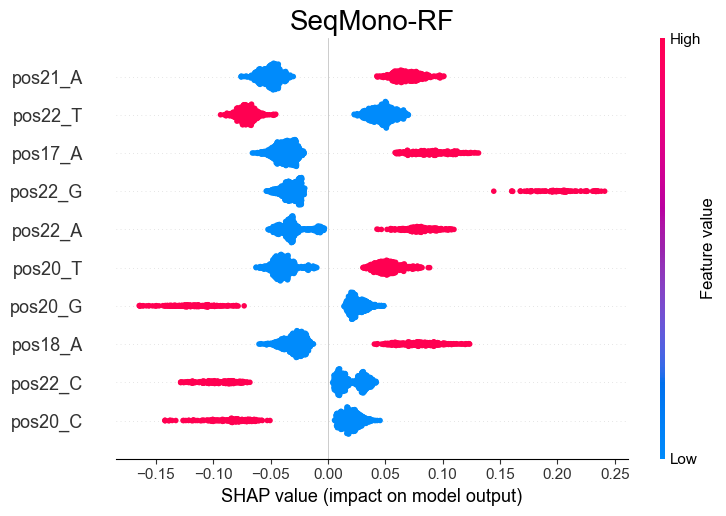

In [18]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

plt.close("all")

# --- Align features ---
if not isinstance(Xte, pd.DataFrame):
    Xte_df = pd.DataFrame(Xte, columns=rf.feature_names_in_)
else:
    Xte_df = Xte.copy()

Xte_df = Xte_df[rf.feature_names_in_]

# --- Subsample ---
n_sample = min(len(Xte_df), 1000)
Xte_df = Xte_df.sample(n_sample, random_state=42)

# --- SHAP ---
explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(Xte_df, approximate=True)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# --- Top features ---
top_k = 10
mean_abs = np.abs(shap_vals).mean(axis=0)
idx = np.argsort(mean_abs)[::-1][:top_k]

X_top = Xte_df.iloc[:, idx]
shap_top = shap_vals[:, idx]

# --- Plot ---
plt.figure(figsize=(5, 3.2))
shap.summary_plot(
    shap_top,
    X_top,
    feature_names=X_top.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)

plt.title("SeqMono-RF")
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
# --- Fade vertical zero line ---
ax = plt.gca()

for line in ax.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
        line.set_alpha(0.7)
        line.set_linewidth(0.5)
# --- Save ---
os.makedirs("Importance_Picture", exist_ok=True)
outpath = "Importance_Picture/SeqMono-RF_NEW.pdf"

print("Saving to:", os.path.abspath(outpath))
plt.savefig(outpath, bbox_inches="tight")

plt.show()
plt.close("all")

Sequence model prediction (LogGFP) for candidate: 2.3320184961855555


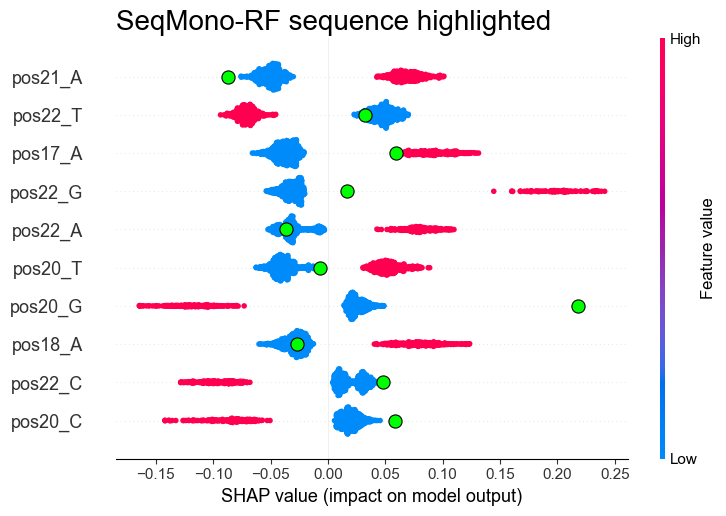

In [31]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ================== USER INPUT ==================
full_seq = "GAAATAACTTCTTGTTTGAACAGGGCT".upper()

#GAAACAATGGATATTTAACTAATGGCT low
seq_model = rf
Xte_seq = Xte

SEQ_COL = "sequence"
KEEP_WINDOW = ("span", 5, 23)   # positions 5–23, 19 positions
# =================================================


def build_X(
    df: pd.DataFrame,
    window=KEEP_WINDOW
) -> pd.DataFrame:

    NUCS = "ACGT"

    seqs = (
        df[SEQ_COL]
        .astype(str)
        .str.upper()
        .str.replace("U", "T", regex=False)
        .map(lambda s: "".join(ch for ch in s if ch in NUCS))
    )

    if window[0] == "all":
        L = seqs.str.len().min()
        start, end = 0, L - 1
    else:
        _, start, end = window

    n_pos = end - start + 1

    cols = [f"pos{p}_{n}" for p in range(start, end + 1) for n in NUCS]
    Xpos = np.zeros((len(seqs), n_pos * 4), float)

    for i, s in enumerate(seqs):
        s_padded = (s + "N" * (end + 1 - len(s)))[: end + 1]

        for p in range(start, end + 1):
            b = s_padded[p]
            if b in NUCS:
                Xpos[i, (p - start) * 4 + NUCS.index(b)] = 1.0

    return pd.DataFrame(Xpos, columns=cols, index=df.index)


# ---- Background matrix ----
if not isinstance(Xte_seq, pd.DataFrame):
    X_bg_seq = pd.DataFrame(Xte_seq, columns=seq_model.feature_names_in_)
else:
    X_bg_seq = Xte_seq.copy()

X_bg_seq = X_bg_seq[seq_model.feature_names_in_]
X_bg_seq = X_bg_seq.sample(min(len(X_bg_seq), 1000), random_state=42)

# ---- Candidate encoding ----
cand_df = pd.DataFrame({SEQ_COL: [full_seq]})

X_cand_seq = build_X(cand_df)
X_cand_seq = X_cand_seq[seq_model.feature_names_in_]

# ---- Prediction ----
y_pred_cand_seq = seq_model.predict(X_cand_seq)

print(
    "Sequence model prediction (LogGFP) for candidate:",
    float(np.array(y_pred_cand_seq).ravel()[0])
)

# ---- SHAP ----
explainer = shap.TreeExplainer(
    seq_model,
    feature_perturbation="tree_path_dependent"
)

shap_bg = explainer.shap_values(X_bg_seq, approximate=True)
shap_bg_vals = shap_bg[1] if isinstance(shap_bg, list) else shap_bg

shap_cand = explainer.shap_values(X_cand_seq, approximate=True)
shap_cand_vals = shap_cand[1] if isinstance(shap_cand, list) else shap_cand

# ---- Top-k ----
top_k = 10

mean_abs = np.abs(shap_bg_vals).mean(axis=0)
idx = np.argsort(mean_abs)[::-1][:top_k]

X_top_bg = X_bg_seq.iloc[:, idx]
shap_top_bg = shap_bg_vals[:, idx]
shap_top_cand = shap_cand_vals[:, idx]

# ---- Plot ----
plt.figure(figsize=(5, 3.2))

shap.summary_plot(
    shap_top_bg,
    X_top_bg,
    feature_names=X_top_bg.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)

ax = plt.gca()

# soften vertical zero line
for line in ax.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
        line.set_alpha(0.2)
        line.set_linewidth(0.5)

# green candidate dots
for y_idx in range(top_k):
    plt.scatter(
        shap_top_cand[0, y_idx],
        y_idx,
        s=90,
        facecolor="lime",
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

plt.title("SeqMono-RF sequence highlighted", loc="left")
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.savefig("SeqMono_RF_candidate_highlighted_variant high ranke.pdf", bbox_inches="tight")
plt.show()

Blue points (Train): predictions on your training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

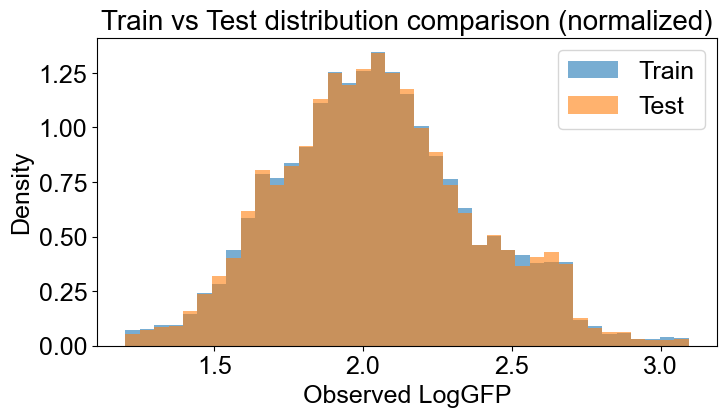

In [12]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(y.min(), y.max(), 40)  # same bins for both

plt.figure(figsize=(8, 4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP")
plt.ylabel("Density")
plt.title("Train vs Test distribution comparison (normalized)")
plt.legend()
plt.show()


see the distribution

77874 19469 4.0
Middle counts 1.90–2.00: train= 9649 test= 2435


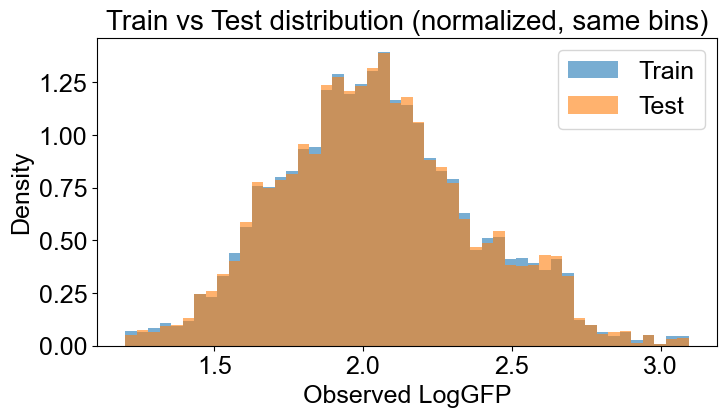

Train quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.951
0.5    2.031
0.6    2.105
0.7    2.197
0.8    2.314
0.9    2.506
1.0    3.094
dtype: float64

Test quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.950
0.5    2.031
0.6    2.106
0.7    2.197
0.8    2.313
0.9    2.505
1.0    3.094
dtype: float64


In [13]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) Confirm sizes (should be ~80/20)
print(len(ytr), len(yte), round(len(ytr)/len(yte), 3))

# 2) Count samples in the “middle” band, e.g. 1.90–2.00
mid_mask_tr = (ytr >= 1.90) & (ytr <= 2.00)
mid_mask_te = (yte >= 1.90) & (yte <= 2.00)
print("Middle counts 1.90–2.00:",
      "train=", mid_mask_tr.sum(),
      "test=",  mid_mask_te.sum())

# 3) Compare shapes with SAME bins and density (so areas match)
bins = np.linspace(y.min(), y.max(), 50)
plt.figure(figsize=(8,4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP"); plt.ylabel("Density")
plt.title("Train vs Test distribution (normalized, same bins)")
plt.legend(); plt.show()

# 4) Quantile table to see coverage across the range
qs = np.linspace(0,1,11)
print("Train quantiles:\n", pd.Series(ytr).quantile(qs).round(3))
print("\nTest quantiles:\n",  pd.Series(yte).quantile(qs).round(3))


save the model

In [14]:
import joblib, json, time

# Safely grab things from the current kernel, defaulting to None when missing
CALIBRATOR     = locals().get("calib", None)            # e.g., ("iso", iso_model) or None
SEQ_FEATURIZER = locals().get("seq_featurizer", None)   # your featurizer or None

# Required bits — assert so you get a clear message if something is missing
rf        = locals().get("rf", None)        # trained regressor
imp       = locals().get("imp", None)       # SimpleImputer or None
Xtr       = locals().get("Xtr", None)       # training features DataFrame
SEQ_COL   = locals().get("SEQ_COL", "sequence")
LABEL_COL = locals().get("LABEL_COL", "logGFP")
SEED      = locals().get("SEED", 42)

assert rf  is not None,  "rf (trained model) is not defined"
assert Xtr is not None,  "Xtr (training features) is not defined"

bundle = {
    "version": "seq_rf_v1",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "seq_col":  SEQ_COL,
    "seed": SEED,
    "rf_params": getattr(rf, "get_params", lambda: {})(),

    # columns AFTER featurization/selection (what the model expects)
    "feature_columns": list(Xtr.columns),

    # preprocessing artifacts
    "imputer": imp,                 # may be None
    "calibrator": CALIBRATOR,       # may be None
    "featurizer": SEQ_FEATURIZER,   # may be None

    # the trained model
    "model": rf,
}
bundle["y_true_te"]       = yte
bundle["y_pred_te_seq"]  = yhat_te_seq

joblib.dump(bundle, "seq76_rf_model.joblib")
print("Saved: seq76_rf_model.joblib")

# Lightweight metadata (no big objects)
meta = {
    k: (v if isinstance(v, (str,int,float,bool,tuple,list,dict)) else str(type(v)))
    for k,v in bundle.items()
    if k not in ["imputer","model","calibrator","featurizer"]
}
with open("seq76_rf_model.meta.json","w") as f:
    json.dump(meta, f, indent=2)
print("Saved: seq76_rf_model.meta.json")


Saved: seq76_rf_model.joblib
Saved: seq76_rf_model.meta.json


In [15]:
import joblib
import numpy as np

B = joblib.load("seq76_rf_model.joblib")

print("Keys in bundle:", B.keys())
y_true = B["y_true_te"]
y_pred = B["y_pred_te_seq"]

print("Lengths:", len(y_true), len(y_pred))
print("First 5 pairs:")
for t, p in list(zip(y_true, y_pred))[:5]:
    print(f"  true={t:.3f}, pred={p:.3f}")

print("Feature columns:", len(B["feature_columns"]))
print(B["feature_columns"][:5])


Keys in bundle: dict_keys(['version', 'trained_at', 'label_col', 'seq_col', 'seed', 'rf_params', 'feature_columns', 'imputer', 'calibrator', 'featurizer', 'model', 'y_true_te', 'y_pred_te_seq'])
Lengths: 19469 19469
First 5 pairs:
  true=2.709, pred=2.641
  true=1.886, pred=1.888
  true=2.202, pred=2.278
  true=2.093, pred=1.838
  true=2.186, pred=2.084
Feature columns: 76
['pos5_A', 'pos5_C', 'pos5_G', 'pos5_T', 'pos6_A']


prediction

In [16]:
import joblib, pandas as pd, numpy as np

# load saved model
B  = joblib.load("seq76_rf_model.joblib")
rf = B["model"]
imp = B.get("imputer", None)

# --- calibrator: handle None / tuple / dict ---
cal = B.get("calibrator", None)
if cal is None:
    calib_name, calib_obj = None, None
elif isinstance(cal, tuple) and len(cal) == 2:
    calib_name, calib_obj = cal
elif isinstance(cal, dict) and {"xp","fp"} <= set(cal.keys()):
    calib_name, calib_obj = "qmap", cal
else:
    raise ValueError(f"Unrecognized calibrator format: {type(cal)}")

feature_cols = B["feature_columns"]

# load your new CSV with sequences
NEW_FILE = "All_Fasta_sequnes_constructed_features.csv"
df_new = pd.read_csv(NEW_FILE)

# rebuild features (same as training)
Xnew = build_X(
    df_new,
    window=B.get("window", ("span", 6, 24)),
    kmer_ks=B.get("kmer_ks", (2, 3)),
    collapse_rc=B.get("collapse_rc", True),
    add_global=True,
)

# align to training feature order
Xnew = Xnew.reindex(columns=feature_cols)
Xnew = Xnew.apply(pd.to_numeric, errors="coerce")

# impute if we saved an imputer; otherwise pass through
if imp is not None:
    Xnew_imp = pd.DataFrame(imp.transform(Xnew), columns=feature_cols, index=Xnew.index)
else:
    Xnew_imp = Xnew

# predict
y_raw = rf.predict(Xnew_imp).astype(float)

# calibrate if available
if calib_name == "iso":
    y_pred = calib_obj.predict(y_raw)
elif calib_name == "qmap":
    xp, fp = calib_obj["xp"], calib_obj["fp"]
    y_pred = np.interp(y_raw, xp, fp)
else:
    y_pred = y_raw  # no calibrator

# attach and save
out = df_new.copy()
out["LogGFP_pred"] = y_pred
out.to_csv("new_sequences_with_predictions.csv", index=False)
print("Saved: new_sequences_with_predictions.csv")


Saved: new_sequences_with_predictions.csv


sanitary check to see if the same training then prediciton

In [17]:
# 1) Make sure the bundle's featurization settings match this run
print("Bundle window:", B.get("window"))
print("Bundle kmer_ks:", B.get("kmer_ks"))
print("Bundle collapse_rc:", B.get("collapse_rc"))

# 2) Confirm columns line up exactly
missing = [c for c in feature_cols if c not in Xnew.columns]
extra   = [c for c in Xnew.columns if c not in feature_cols]
print("Missing:", missing[:10], "…", len(missing))
print("Extra:",   extra[:10],   "…", len(extra))

assert not missing, "Your build_X settings don't match training (missing features)."
Xnew = Xnew.reindex(columns=feature_cols)

# 3) Ensure no NaNs before predict (or impute)
if imp is None:
    assert not np.isnan(Xnew.to_numpy()).any(), "NaNs found; impute or clean inputs."


Bundle window: None
Bundle kmer_ks: None
Bundle collapse_rc: None
Missing: [] … 0
Extra: [] … 0


AssertionError: NaNs found; impute or clean inputs.

In [ ]:

import pandas as pd
import numpy as np

# ===== 1) Input: set this to the file your previous step wrote =====
INFILE = "new_sequences_with_predictions.csv"   # <- produced by the loader
# If you saved TSV instead, use: INFILE = "seq_predictions.tsv"

# Auto-detect separator
df = pd.read_csv(INFILE, sep=None, engine="python")

# ===== 2) Identify columns =====
score_candidates = ["LogGFP_pred", "LOG_GFP", "prediction"]
seq_candidates   = ["sequence", "Sequence", "seq"]

score_col = next((c for c in score_candidates if c in df.columns), None)
seq_col   = next((c for c in seq_candidates   if c in df.columns), None)

assert score_col is not None, f"No prediction column found in {INFILE}. Tried {score_candidates}"
assert seq_col   is not None, f"No sequence column found in {INFILE}. Tried {seq_candidates}"

print(f"Using prediction column: {score_col}")
print(f"Using sequence column:   {seq_col}")

# Helper to add core19 safely (flanks 4 nt each)
def add_core19(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y.loc[:, "core19"] = y[seq_col].astype(str).map(lambda s: s[4:-4] if len(s) >= 9 else s)
    return y

# ===== 3) Top 3 strongest =====
top3 = df.sort_values(score_col, ascending=False).head(3).copy()
top3 = add_core19(top3)
top3.to_csv("predictions_top3_4_sequence_RF.tsv", sep="\t", index=False)

# ===== 4) Bottom 3 weakest =====
bottom3 = df.sort_values(score_col, ascending=True).head(3).copy()
bottom3 = add_core19(bottom3)
bottom3.to_csv("predictions_bottom3_4_sequence_RF.tsv", sep="\t", index=False)

print("Wrote:")
print(" - predictions_top3_4_sequence_RF.tsv     (strongest 3 overall)")
print(" - predictions_bottom3_4_sequence_RF.tsv  (weakest 3 overall)")

# ===== 5) Six bins over prediction range, 1 sequence per bin =====

# First, add core19 to the full df
df_with_core = add_core19(df)

# Try to create 6 quantile bins; if there are too few unique scores, qcut can complain
try:
    df_with_core["bin6"] = pd.qcut(df_with_core[score_col], q=6, labels=False, duplicates="drop")
except ValueError as e:
    print("Warning during qcut (probably too few unique scores), falling back to 6 equal-width bins.")
    df_with_core["bin6"] = pd.cut(df_with_core[score_col], bins=6, labels=False)

# For reproducibility: sort within each bin by prediction (e.g. take the median-ish one)
# Here we just take the first row in each bin after sorting by score
df_with_core = df_with_core.sort_values(score_col)

# Pick exactly one representative sequence per bin
one_per_bin = (
    df_with_core
    .dropna(subset=["bin6"])
    .groupby("bin6", as_index=False)
    .head(1)  # first row per bin
    .sort_values("bin6")  # order bins 0..5
)

# Keep only the relevant columns
one_per_bin_out = one_per_bin[[seq_col, "core19", score_col, "bin6"]]

one_per_bin_out.to_csv("predictions_6bins_1seq_each_RF.tsv", sep="\t", index=False)

print(" - predictions_6bins_1seq_each_RF.tsv  (6 bins, 1 sequence per bin)")
print(one_per_bin_out)

# Make sure we have the core19
df_with_core = add_core19(df)

# Define what you consider "high expression"
threshold = 2.0
high = df_with_core[df_with_core[score_col] >= threshold].copy()

# Targets in log space you want to sample around
targets = [2.28, 2.49, 2.52]

picked_rows = []
for t in targets:
    # index of the row whose prediction is closest to t
    idx = (high[score_col] - t).abs().idxmin()
    picked_rows.append(high.loc[idx])

picked = pd.DataFrame(picked_rows).drop_duplicates(subset=[seq_col])

# Keep only relevant columns
picked_out = picked[[seq_col, "core19", score_col]]

picked_out.to_csv("picked_high_sequences_near_targets.tsv", sep="\t", index=False)

print("Picked sequences near targets", targets)
print(picked_out)



Using prediction column: LogGFP_pred
Using sequence column:   sequence
Wrote:
 - predictions_top3_4_sequence_RF.tsv     (strongest 3 overall)
 - predictions_bottom3_4_sequence_RF.tsv  (weakest 3 overall)
 - predictions_6bins_1seq_each_RF.tsv  (6 bins, 1 sequence per bin)
                       sequence               core19  LogGFP_pred  bin6
0   AAAGCTGGGTGTGAAAAGGGCTTGGCT  CTGGGTGTGAAAAGGGCTT     1.609474     0
9   AAAGCCAGTCATATCAATTACATGGCT  CCAGTCATATCAATTACAT     1.851089     1
8   AAAGTAGGATAGTCCATGAGTTTGGCT  TAGGATAGTCCATGAGTTT     1.927528     2
2   AAAGGAAACAGGGTTGCACATTGGGCT  GAAACAGGGTTGCACATTG     2.456357     3
14  AAAGACCAAGCCATAAGCAAAAAGGCT  ACCAAGCCATAAGCAAAAA     2.478874     4
3   AAAGACTAGGTCTAGACACAAAGGGCT  ACTAGGTCTAGACACAAAG     2.528700     5
Picked sequences near targets [2.28, 2.49, 2.52]
                       sequence               core19  LogGFP_pred
6   AAAGGTTAAAAATTTTGCAATTAGGCT  GTTAAAAATTTTGCAATTA     2.396838
12  AAAGTGGACTGATATATACAAAAGGCT  TGGACTGATA

the 6 bins, and then weakest and strongest sequnce

In [ ]:
import pandas as pd
import numpy as np

# ===== 1) Input: set this to the file your previous step wrote =====
INFILE = "new_sequences_with_predictions.csv"   # <- produced by the loader
# If you saved TSV instead, use: INFILE = "seq_predictions.tsv"

# Auto-detect separator
df = pd.read_csv(INFILE, sep=None, engine="python")

# ===== 2) Identify columns =====
score_candidates = ["LogGFP_pred"]
seq_candidates   = ["sequence", "Sequence"]

score_col = next((c for c in score_candidates if c in df.columns), None)
seq_col   = next((c for c in seq_candidates   if c in df.columns), None)

assert score_col is not None, f"No prediction column found in {INFILE}. Tried {score_candidates}"
assert seq_col   is not None, f"No sequence column found in {INFILE}. Tried {seq_candidates}"

# Helper to add core19 safely
def add_core19(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y.loc[:, "core19"] = y[seq_col].astype(str).map(lambda s: s[4:-4] if len(s) >= 9 else s)
    return y

# ===== 3) Top 3 strongest =====
top3 = df.sort_values(score_col, ascending=False).head(3).copy()
top3 = add_core19(top3)
top3.to_csv("predictions_top3_4_sequence__RF.tsv", sep="\t", index=False)

# ===== 4) Bottom 3 weakest =====
bottom3 = df.sort_values(score_col, ascending=True).head(3).copy()
bottom3 = add_core19(bottom3)
bottom3.to_csv("predictions_bottom3_4_sequence_RF.tsv", sep="\t", index=False)

print("Wrote:")
print(" - predictions_top3_4_sequence_RF.tsv     (strongest 3 overall)")
print(" - predictions_bottom3_4_sequence_RF.tsv  (weakest 3 overall)")


Wrote:
 - predictions_top3_4_sequence_RF.tsv     (strongest 3 overall)
 - predictions_bottom3_4_sequence_RF.tsv  (weakest 3 overall)


In [ ]:
import pandas as pd

df = pd.read_csv("new_sequences_with_predictions.csv")

def lookup(seq):
    print(df.loc[df["sequence"] == seq, ["sequence", "LogGFP_pred"]])

lookup("AAAGACTAGGTCTAGACACAAAGGGCT")


                      sequence  LogGFP_pred
3  AAAGACTAGGTCTAGACACAAAGGGCT       2.5287


look up more sequnces

In [ ]:
import pandas as pd

# ============================
# 1. Load BIG prediction file
# ============================

big = pd.read_csv("new_sequences_with_predictions.csv")  # comma-separated by default
big = big.rename(columns={
    "sequence": "full_seq",
    "LogGFP_pred": "prediction"
})

# Strip AAAG in front & GGCT at end
big["core19"] = (
    big["full_seq"]
    .str.replace("^AAAG", "", regex=True)
    .str.replace("GGCT$", "", regex=True)
)

# Ensure max length 19 (safety)
big["core19"] = big["core19"].str.slice(0, 19)

# Keep only needed columns
big = big[["core19", "prediction"]]


# ============================
# 2. Load SMALL file
# ============================
small = pd.read_csv("new_sequnces.csv")    # comma-separated
small = small[["seq"]]                            # keep only this column

# Preserve original order
small["order"] = range(len(small))


# ============================
# 3. Merge WITHOUT sorting by prediction
# ============================
merged = small.merge(
    big,
    left_on="seq",
    right_on="core19",
    how="left"
)

# Keep only seq + prediction
result = merged[["seq", "prediction", "order"]]

# Restore the original order of the small file
result = result.sort_values("order").drop(columns="order")


# ============================
# 4. Save
# ============================
result.to_csv("seq_and_predictions.tsv", sep="\t", index=False)

print("Saved: seq_and_predictions.tsv")
print(result.head())


FileNotFoundError: [Errno 2] No such file or directory: 'new_sequnces.csv'